## Analysis of the simulations output



Analysis of the files obtained in JWST server, using 500 combinations of parameters.

- Tmax = 5000 generations (or more if needed)
- Number of replicates = 10000 replicates (two rounds of 5000 replicates)
- Size of array = 40 spacers
- Script: simulate_spacers1.2

In [1]:
import glob
import pandas as pd
import re 

def load_file(file_path):
    # Load the data, skipping the first 5 lines
    data = pd.read_csv(file_path, delim_whitespace=True, skiprows=5) 
    return data

# Specify the folder path and file pattern
folder_path = "/Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/OUTPUTS/OUTPUT_means_230425/"
file_pattern = r"OutputFile_0.*.txt" ##Quito temporalmente los de a=1.00 porque al ser efficacy y fitness 0 da error

# Get a list of all files matching the pattern
file_paths = glob.glob(folder_path + file_pattern)
data_dict = {file_path: load_file(file_path) for file_path in file_paths}

# Verify data
#for file, data in data_dict.items():
#    print(f"Data for {file}:\n", data)

In [2]:
columns = next(iter(data_dict.values())).columns  # Get columns from the first DataFrame(with next and iter)
print(columns)

Index(['beta', 'age', 'efficacy', 'fitness', 'endemicBeta', 'epidemicBeta'], dtype='object')


### Ratio between maxima, position of minimum and FWHM (Full Width at Half Maximum)

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import glob
import numpy as np
import math 
import os

# Linear interpolation to find the index corresponding to the midpoint value
def find_interpolated_index(x_values, y_values, midpoint_value):
    # Perform linear interpolation to find the corresponding index
    for i in range(len(y_values) - 1):
        if (y_values[i] <= midpoint_value <= y_values[i + 1]) or (y_values[i] >= midpoint_value >= y_values[i + 1]):
            x_left = x_values[i]
            x_right = x_values[i + 1]
            y_left = y_values[i]
            y_right = y_values[i + 1]
            # Linear interpolation formula: y = y_left + (x - x_left) * (y_right - y_left) / (x_right - x_left)
            interpolated_x = x_left + (midpoint_value - y_left) * (x_right - x_left) / (y_right - y_left)
            return interpolated_x
    return None  # Return None if no interpolation was possible

def find_interpolated_index_reverse(x_values, y_values, midpoint_value):
    for i in range(len(y_values) - 1, 0, -1):
        if (y_values[i] <= midpoint_value <= y_values[i - 1]) or (y_values[i] >= midpoint_value >= y_values[i - 1]):
            x_right = x_values[i]
            x_left = x_values[i - 1]
            y_right = y_values[i]
            y_left = y_values[i - 1]
            
            # Linear interpolation formula: y = y_left + (x - x_left) * (y_right - y_left) / (x_right - x_left)
            interpolated_x = x_left + (midpoint_value - y_left) * (x_right - x_left) / (y_right - y_left)
            return interpolated_x
    return None  # Return None if no interpolation was possible

# Define a function to load the file and find the two highest peaks, including endpoints
def calculate_peak_ratio_including_endpoints(file_path):
    # Load the data, skipping the first 5 lines
    data = pd.read_csv(file_path, delim_whitespace=True, skiprows=5)
    # Extract the fitness column
    fitness = data['fitness']
    
    # Find the lowest peaks (minima) by inverting the fitness values
    minima, _ = find_peaks(-fitness, distance=10)  # Adjust `distance` as needed
    # Get the lowest minimum based on fitness values
    min_point = sorted(minima, key=lambda x: fitness[x])[:1]  # Sort to get the lowest minimum
    
    # Find peaks in the middle of the fitness data
    middle_peaks, _ = find_peaks(fitness, distance=10)
    # Include endpoints as potential maxima
    all_peaks = list(middle_peaks) + [0, len(fitness) - 1]  # Add indices for first and last points
    left_peaks = [p for p in all_peaks if p <= min_point[0]] # Peaks on the left of the minimum
    right_peaks = [p for p in all_peaks if p > min_point[0]] # On the right

    # Calculate the ratio between the two highest peaks
    if left_peaks and right_peaks:
        left_peak = max(left_peaks, key=lambda x: fitness[x])  
        right_peak = max(right_peaks, key=lambda x: fitness[x])  
        ratio = fitness[left_peak] / fitness[right_peak] if fitness[right_peak] != 0 else None
        return min_point, ratio, left_peak, right_peak, fitness[left_peak], fitness[right_peak]
    else:
        return None, None, None, None, None
    
output_file = "ANALYSIS/fitness_data_g60.txt"
with open(output_file, "w") as f:
    f.write("parameters\tmax_left_position\tmax_left_value\tmax_right_position\tmax_right_value\tmin_position\tmin_value\tratio_of_peaks\teuclidean_distance\n")

    for file_path in file_paths:
        data = pd.read_csv(file_path, delim_whitespace=True, skiprows=5)
        fitness = data['fitness']
        x_values = np.arange(len(fitness))
        min_point, ratio, left_peak, right_peak, left_peak_value, right_peak_value = calculate_peak_ratio_including_endpoints(file_path)

        midpoint_left = (fitness[min_point[0]] + left_peak_value) / 2 if min_point else None
        midpoint_right = (fitness[min_point[0]] + right_peak_value) / 2 if min_point else None

        midpoint_left_index = find_interpolated_index(x_values, fitness, midpoint_left) if midpoint_left is not None else None
        midpoint_right_index = find_interpolated_index_reverse(x_values, fitness, midpoint_right) if midpoint_right is not None else None

        p = [midpoint_left_index, midpoint_left] 
        q = [midpoint_right_index, midpoint_right] 

        match = re.search(r'(\d{1,2}\.\d{2}_\d{1,2}\.\d{2}_\d{1,2}\.\d{2})', file_path)
        if match:
            extracted_part = match.group(0)
            f.write(f"{extracted_part}\t{left_peak}\t{left_peak_value}\t{right_peak}\t{right_peak_value}\t{min_point[0]}\t{fitness[min_point[0]]}\t{ratio:.4f}\t{math.dist(p, q):.4f}\n")

print(f"Results saved to {output_file}")

IndexError: list index out of range

## Different morphologies

In [10]:
folder_path = "/Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/OUTPUTS/OUTPUT_means_230425/"
files = os.listdir(folder_path)
target_files = [
    "OutputFile_0.10_60.00_0.50.txt",
    "OutputFile_0.77_60.00_0.50.txt"
]
file_paths = [os.path.join(folder_path, f) for f in files if f in target_files]

File: /Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/OUTPUTS/OUTPUT_means_230425/OutputFile_0.10_60.00_0.50.txt
  Max Left: 0, Value Max Left: 0.87965, Max Right: 28, Value Max Right: 0.97545
  Ratio of Left to Right Peak: 0.9018
  Minpoint : 26, Value : 0.971
  Midpoint Left: 0.9253, Midpoint Right: 0.9732
  Euclidean distance between midpoints: 21.1208


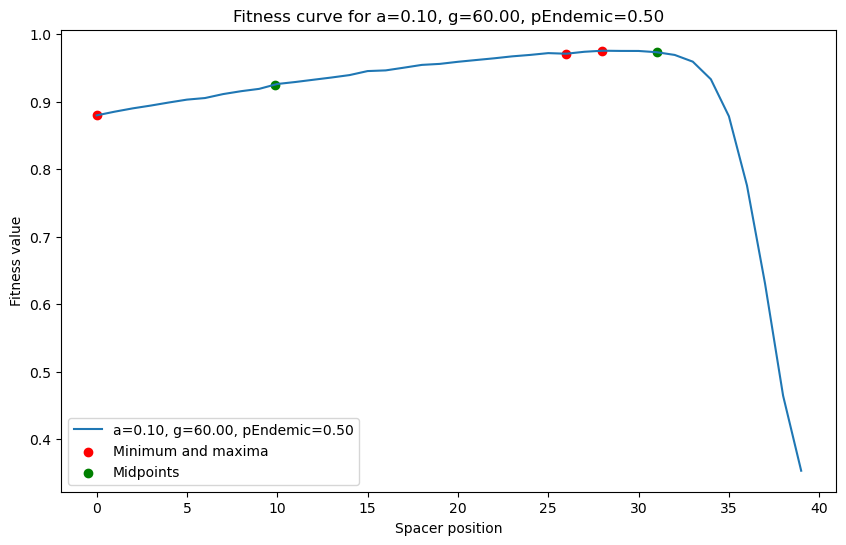

File: /Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/OUTPUTS/OUTPUT_means_230425/OutputFile_0.77_60.00_0.50.txt
  Max Left: 27, Value Max Left: 0.9308, Max Right: 39, Value Max Right: 0.0799
  Ratio of Left to Right Peak: 11.6496
  Minpoint : 28, Value : 0.9276
  Midpoint Left: 0.9292, Midpoint Right: 0.5038
  Euclidean distance between midpoints: 8.9819


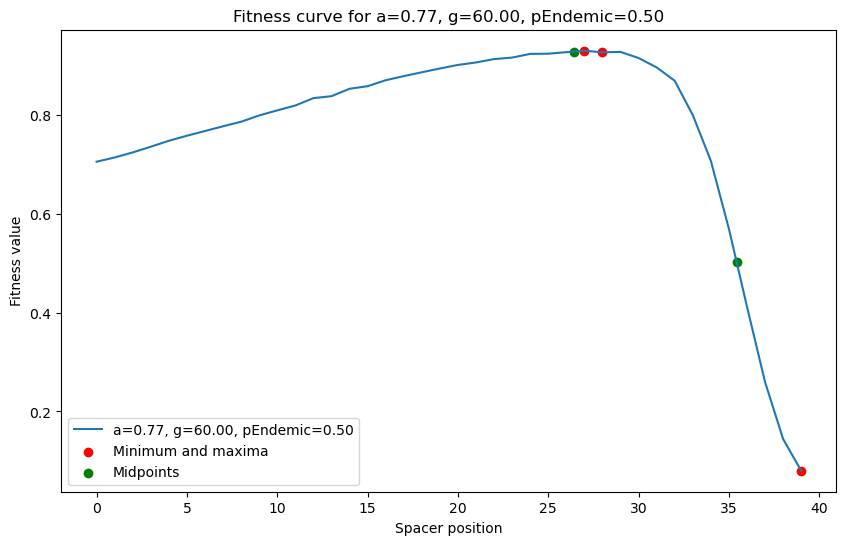

In [11]:
# Loop over each file, calculate the minimum, midpoints, and plot the results
for file_path in file_paths:
    # Load fitness data again for plotting
    data = pd.read_csv(file_path, delim_whitespace=True, skiprows=5)
    fitness = data['fitness']
    x_values = np.arange(len(fitness))  # Create an array of x values (indices of the fitness array)

    # Calculate maxima
    min_point, ratio, left_peak, right_peak, left_peak_value, right_peak_value = calculate_peak_ratio_including_endpoints(file_path)

    # Calculate midpoints for left and right of the minimum
    midpoint_left = (fitness[min_point[0]] + left_peak_value) / 2
    midpoint_right = (fitness[min_point[0]] + right_peak_value) / 2
    
    # Find the indices of midpoints using interpolation
    midpoint_left_index = find_interpolated_index(x_values, fitness, midpoint_left) if midpoint_left is not None else None
    midpoint_right_index = find_interpolated_index_reverse(x_values, fitness, midpoint_right) if midpoint_right is not None else None
    # Calculate Euclidean distance between midpoints
    p = [midpoint_left_index, midpoint_left] 
    q = [midpoint_right_index, midpoint_right] 
    
    # Print the results
    print(f"File: {file_path}")
    print(f"  Max Left: {left_peak}, Value Max Left: {left_peak_value}, Max Right: {right_peak}, Value Max Right: {right_peak_value}")
    if ratio is not None:
        print(f"  Ratio of Left to Right Peak: {ratio:.4f}")
    else:
        print(f"File: {file_path} has an issue with the peak values; cannot calculate ratio.")
    print(f"  Minpoint : {min_point[0]}, Value : {fitness[min_point[0]]}")
    print(f"  Midpoint Left: {midpoint_left:.4f}, Midpoint Right: {midpoint_right:.4f}")
    print(f"  Euclidean distance between midpoints: {math.dist(p, q):.4f}")
    
    # Plotting the fitness curve with the marked minimum and midpoints
    plt.figure(figsize=(10, 6))
    # Extract parameters value from file path
    file_name = os.path.basename(file_path)
    try:
        _, a_str, g_str, p_str = file_name.replace(".txt", "").split("_")
        legend_label = f"a={a_str}, g={g_str}, pEndemic={p_str}"
    except ValueError:
        legend_label = file_name
    plt.plot(fitness, label=legend_label)

    # Plot maxima, minimum and midpoints (if valid)
    if left_peak is not None and right_peak is not None:
        plt.scatter([left_peak, right_peak], [fitness[left_peak], fitness[right_peak]], 
                    color='red')
    if min_point is not None:
        plt.scatter(min_point, fitness[min_point], color='red', label='Minimum and maxima')
    if midpoint_left is not None:
        plt.scatter(midpoint_left_index, midpoint_left, color='green', label='Midpoints')
    if midpoint_right is not None:
        plt.scatter(midpoint_right_index, midpoint_right, color='green')

    plt.title(f"Fitness curve for {legend_label}")
    plt.xlabel("Spacer position")
    plt.ylabel("Fitness value")
    plt.legend()
    plt.show()

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import glob
import numpy as np
import math 
import os

In [2]:
folder_path = "/Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/OUTPUTS/OUTPUT_means_230425/"
files = os.listdir(folder_path)
target_files = [
    "OutputFile_0.10_60.00_0.00.txt",
    "OutputFile_0.10_60.00_0.10.txt",
    "OutputFile_0.10_60.00_0.20.txt",
    "OutputFile_0.10_60.00_0.30.txt",
    "OutputFile_0.10_60.00_0.40.txt",
    "OutputFile_0.10_60.00_0.50.txt",
    "OutputFile_0.10_60.00_0.60.txt",
    "OutputFile_0.10_60.00_0.70.txt",
    "OutputFile_0.10_60.00_0.80.txt",
    "OutputFile_0.77_60.00_0.00.txt"
]
file_paths = [os.path.join(folder_path, f) for f in files if f in target_files]

File: /Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/OUTPUTS/OUTPUT_means_230425/OutputFile_0.10_60.00_0.40.txt


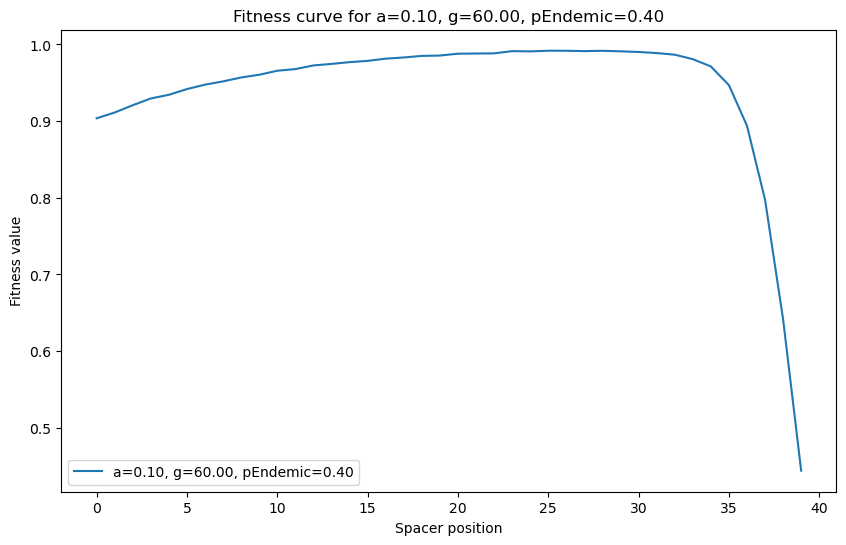

File: /Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/OUTPUTS/OUTPUT_means_230425/OutputFile_0.10_60.00_0.80.txt


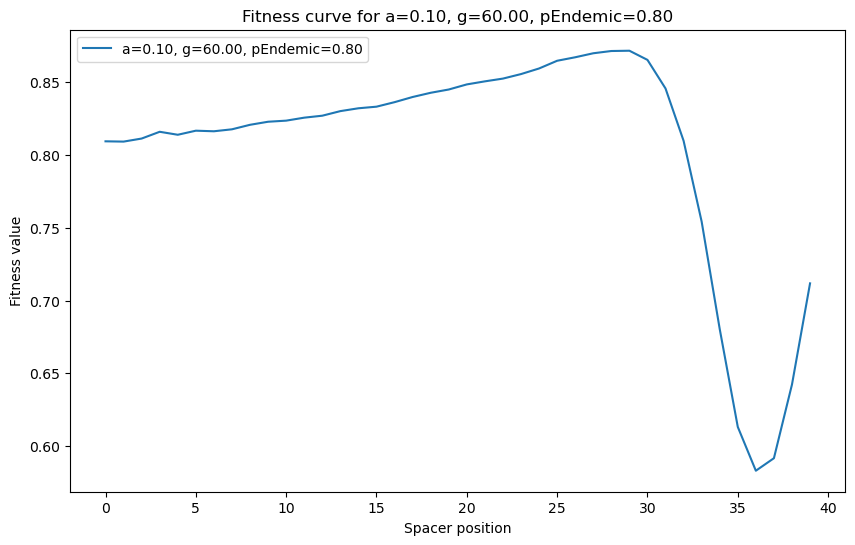

File: /Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/OUTPUTS/OUTPUT_means_230425/OutputFile_0.10_60.00_0.50.txt


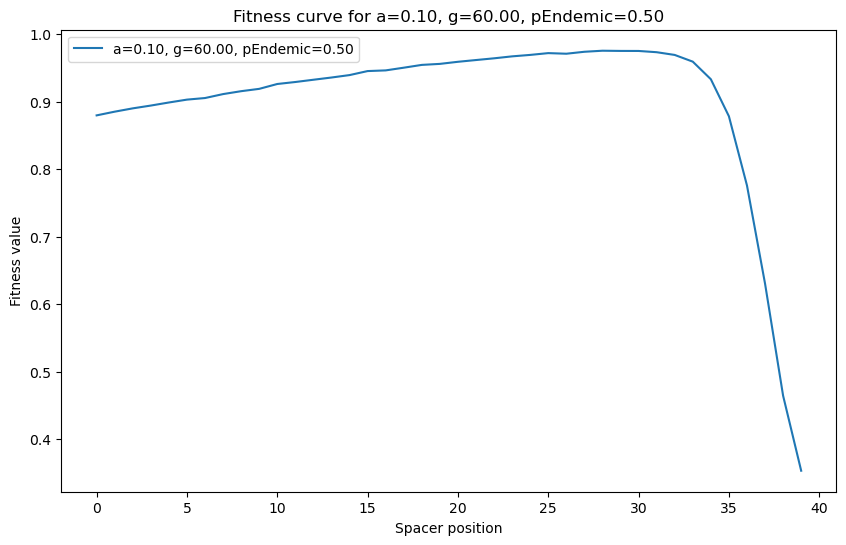

File: /Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/OUTPUTS/OUTPUT_means_230425/OutputFile_0.10_60.00_0.20.txt


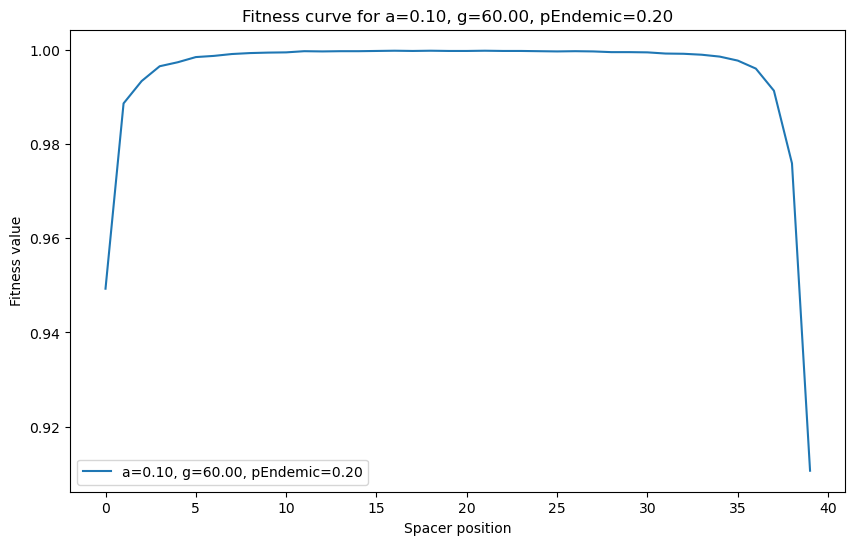

File: /Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/OUTPUTS/OUTPUT_means_230425/OutputFile_0.10_60.00_0.30.txt


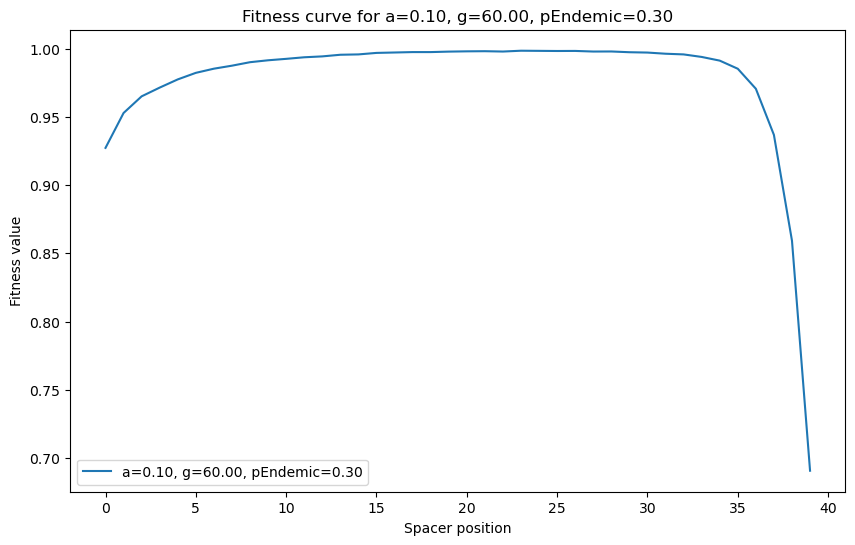

File: /Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/OUTPUTS/OUTPUT_means_230425/OutputFile_0.10_60.00_0.00.txt


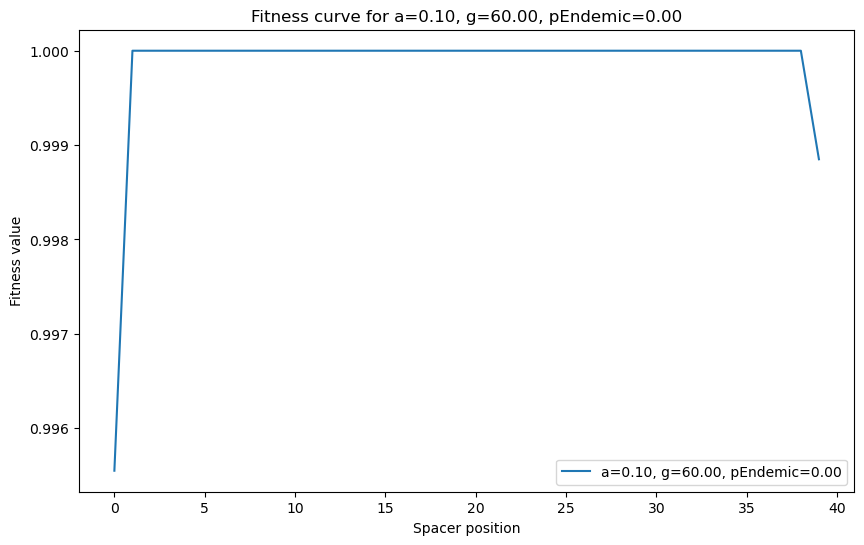

File: /Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/OUTPUTS/OUTPUT_means_230425/OutputFile_0.10_60.00_0.10.txt


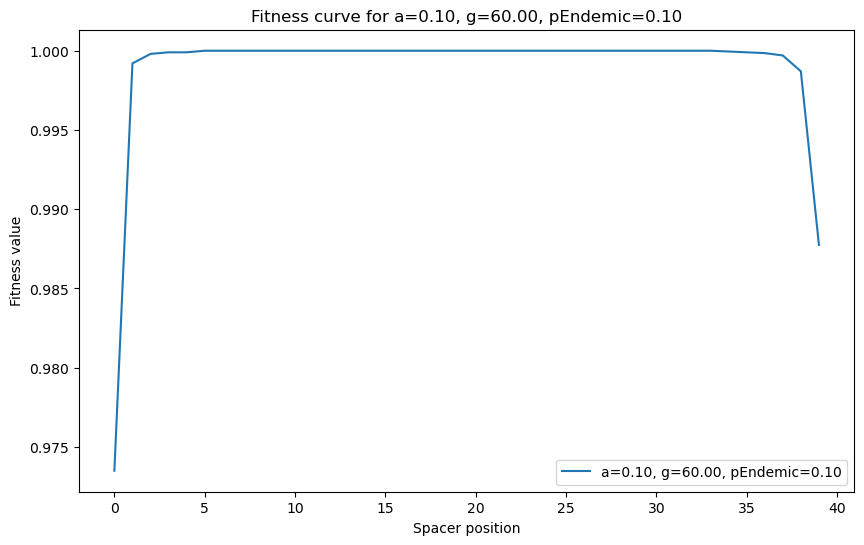

File: /Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/OUTPUTS/OUTPUT_means_230425/OutputFile_0.10_60.00_0.60.txt


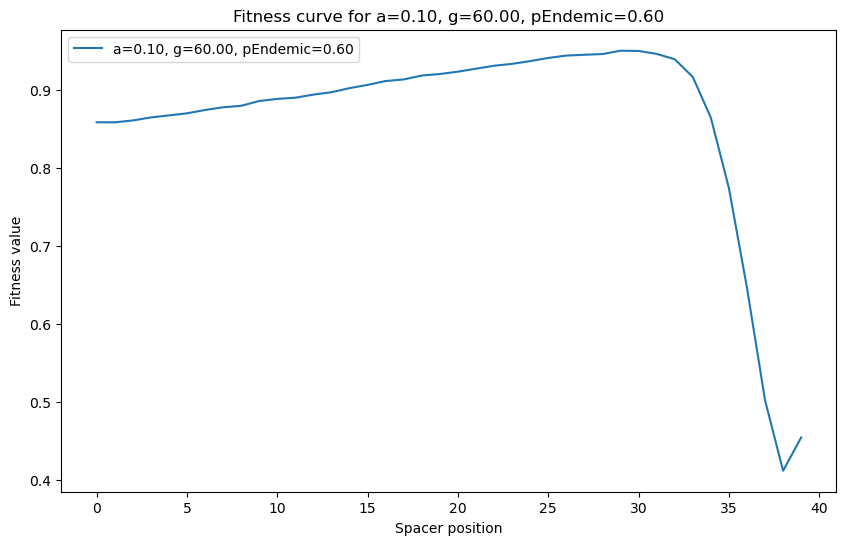

File: /Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/OUTPUTS/OUTPUT_means_230425/OutputFile_0.77_60.00_0.00.txt


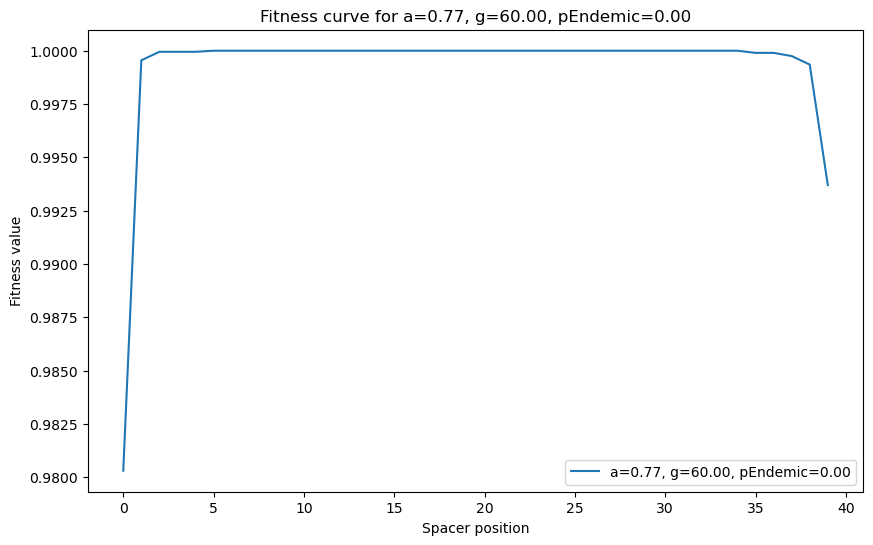

File: /Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/OUTPUTS/OUTPUT_means_230425/OutputFile_0.10_60.00_0.70.txt


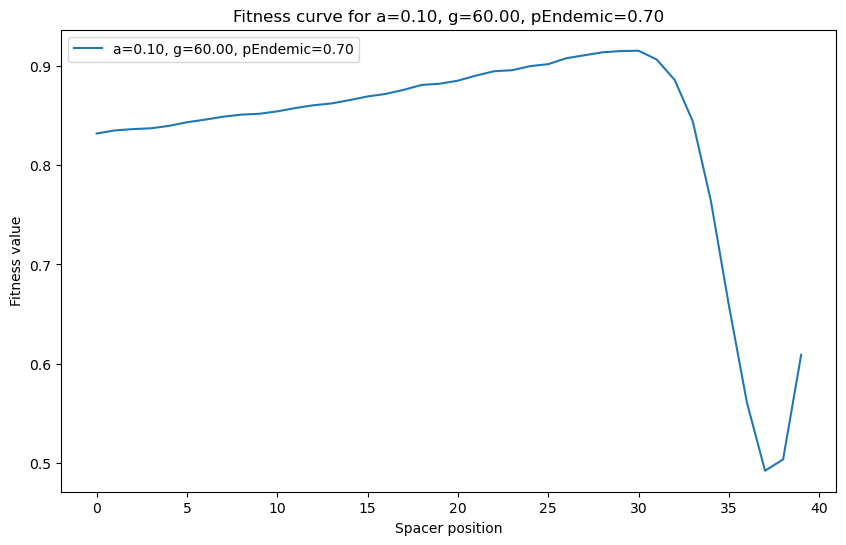

In [3]:
# Loop over each file, calculate the minimum, midpoints, and plot the results
for file_path in file_paths:
    # Load fitness data again for plotting
    data = pd.read_csv(file_path, delim_whitespace=True, skiprows=5)
    fitness = data['fitness']
    x_values = np.arange(len(fitness))  # Create an array of x values (indices of the fitness array)
    # Print the results
    print(f"File: {file_path}")
    # Plotting the fitness curve with the marked minimum and midpoints
    plt.figure(figsize=(10, 6))
    # Extract parameters value from file path
    file_name = os.path.basename(file_path)
    try:
        _, a_str, g_str, p_str = file_name.replace(".txt", "").split("_")
        legend_label = f"a={a_str}, g={g_str}, pEndemic={p_str}"
    except ValueError:
        legend_label = file_name
    plt.plot(fitness, label=legend_label)
    plt.title(f"Fitness curve for {legend_label}")
    plt.xlabel("Spacer position")
    plt.ylabel("Fitness value")
    plt.legend()
    plt.show()

## See age profiles to verify one hypothesis

In [5]:
folder_path = "/Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/OUTPUTS/OUTPUT_means_230425/"
files = os.listdir(folder_path)
target_files = [
    "OutputFile_0.10_60.00_0.50.txt",
    "OutputFile_0.77_60.00_0.50.txt"
]
file_paths = [os.path.join(folder_path, f) for f in files if f in target_files]

File: /Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/OUTPUTS/OUTPUT_means_230425/OutputFile_0.10_60.00_0.50.txt


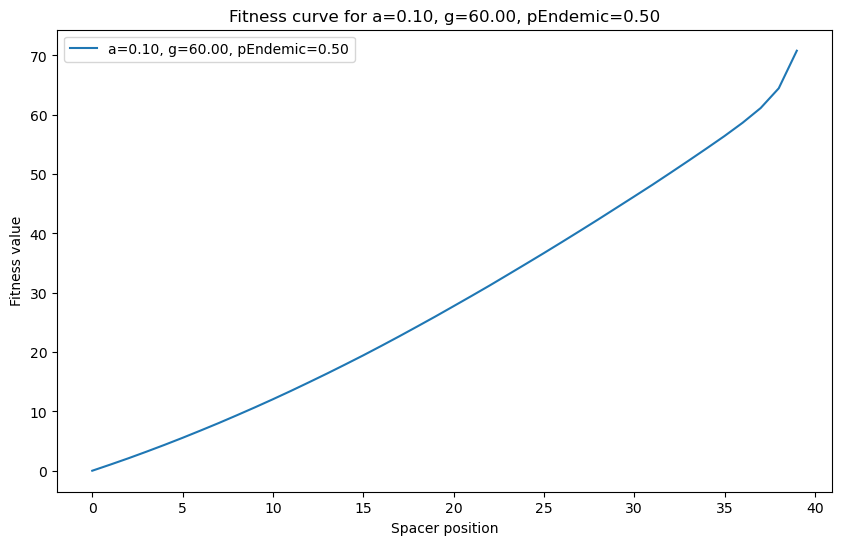

File: /Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/OUTPUTS/OUTPUT_means_230425/OutputFile_0.77_60.00_0.50.txt


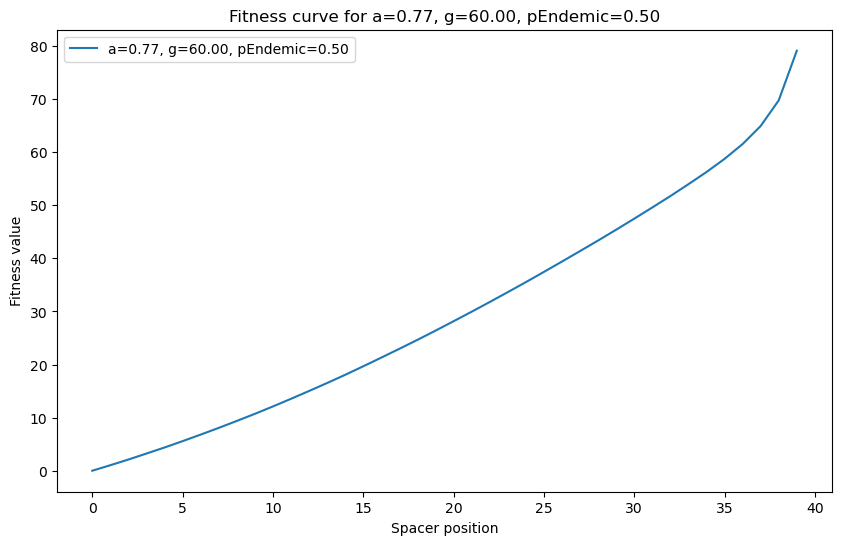

In [6]:
# Loop over each file, calculate the minimum, midpoints, and plot the results
for file_path in file_paths:
    # Load fitness data again for plotting
    data = pd.read_csv(file_path, delim_whitespace=True, skiprows=5)
    fitness = data['age']
    x_values = np.arange(len(fitness))  # Create an array of x values (indices of the fitness array)
    # Print the results
    print(f"File: {file_path}")
    # Plotting the fitness curve with the marked minimum and midpoints
    plt.figure(figsize=(10, 6))
    # Extract parameters value from file path
    file_name = os.path.basename(file_path)
    try:
        _, a_str, g_str, p_str = file_name.replace(".txt", "").split("_")
        legend_label = f"a={a_str}, g={g_str}, pEndemic={p_str}"
    except ValueError:
        legend_label = file_name
    plt.plot(fitness, label=legend_label)
    plt.title(f"Fitness curve for {legend_label}")
    plt.xlabel("Spacer position")
    plt.ylabel("Fitness value")
    plt.legend()
    plt.show()

### References
https://stackoverflow.com/questions/59163774/python-how-to-find-and-visually-mark-the-local-minima-of-a-sequence

https://www.w3schools.com/python/ref_math_dist.asp --> Euclidean distance between two points